In [22]:
import os
import pandas as pd
import mlflow
import joblib
from mlflow.tracking import MlflowClient

# =========================================================
# 0) Connexion MLflow
# =========================================================
TRACKING_URI = "http://127.0.0.1:5000"
EXP_NAME = "Multivariate_ML_Experimentation"
DL_DIR = "mlflow_import"

os.makedirs(DL_DIR, exist_ok=True)

mlflow.set_tracking_uri(TRACKING_URI)
client = MlflowClient()

exp = mlflow.get_experiment_by_name(EXP_NAME)
if exp is None:
    raise ValueError(f"Experiment introuvable: {EXP_NAME}")

runs = mlflow.search_runs([exp.experiment_id], output_format="pandas")
if runs.empty:
    raise ValueError("Aucun run trouvé.")

runs = runs.sort_values("start_time", ascending=False).reset_index(drop=True)

print("✅ runs:", len(runs))

# =========================================================
# Helpers
# =========================================================
def list_artifacts_recursive(run_id: str, path: str = ""):
    out = []
    stack = [path]
    while stack:
        p = stack.pop()
        try:
            items = client.list_artifacts(run_id, p)
        except Exception:
            continue
        for a in items:
            out.append(a)
            if a.is_dir:
                stack.append(a.path)
    return out

def download(run_id: str, artifact_path: str):
    return client.download_artifacts(run_id, artifact_path, dst_path=DL_DIR)

# =========================================================
# 1) Dernier run par (model_label, partition)
# =========================================================
runs["model_label"] = runs.get("tags.model_label")
runs["partition"]   = runs.get("tags.partition")

runs_ok = runs.dropna(subset=["model_label", "partition"]).copy()
runs_ok["model_label"] = runs_ok["model_label"].astype(str)
runs_ok["partition"]   = runs_ok["partition"].astype(str)

runs_latest = (
    runs_ok.sort_values("start_time", ascending=False)
           .drop_duplicates(subset=["model_label", "partition"], keep="first")
           .reset_index(drop=True)
)

print("✅ unique (model,partition) runs:", len(runs_latest))

# =========================================================
# 2) Tables globales
# =========================================================
score_df_exp = None
leaderboard_exp = None

for _, r in runs_latest.iterrows():
    rid = r["run_id"]
    arts = list_artifacts_recursive(rid)

    for a in arts:
        if a.is_dir:
            continue
        base = os.path.basename(a.path)

        if base == "score_df_exp.csv" and score_df_exp is None:
            score_df_exp = pd.read_csv(download(rid, a.path))
            print("✅ score_df_exp loaded:", score_df_exp.shape)

        if base == "leaderboard_exp.csv" and leaderboard_exp is None:
            leaderboard_exp = pd.read_csv(download(rid, a.path))
            print("✅ leaderboard_exp loaded:", leaderboard_exp.shape)

    if score_df_exp is not None and leaderboard_exp is not None:
        break

# =========================================================
# 3) Explainability PAR PARTITION
# =========================================================
results_perm_mae_by_part = {}
results_perm_dev_by_part = {}
results_shap_share_by_part = {}

def collect_explainability(run_id: str):
    arts = list_artifacts_recursive(run_id)

    for a in arts:
        if a.is_dir or not a.path.endswith(".csv"):
            continue

        base = os.path.basename(a.path)

        # perm_mae_MODEL_PARTITION.csv
        if base.startswith("perm_mae_"):
            name = base.replace("perm_mae_", "").replace(".csv", "")
            model_label, partition = name.split("_", 1)
            df = pd.read_csv(download(run_id, a.path))
            results_perm_mae_by_part.setdefault(partition, {})[model_label] = df

        # perm_dev_MODEL_PARTITION.csv
        elif base.startswith("perm_dev_"):
            name = base.replace("perm_dev_", "").replace(".csv", "")
            model_label, partition = name.split("_", 1)
            df = pd.read_csv(download(run_id, a.path))
            results_perm_dev_by_part.setdefault(partition, {})[model_label] = df

        # shap_MODEL_PARTITION.csv  (aligné avec nouveau logging)
        elif base.startswith("shap_"):
            name = base.replace("shap_", "").replace(".csv", "")
            model_label, partition = name.split("_", 1)
            df = pd.read_csv(download(run_id, a.path))
            results_shap_share_by_part.setdefault(partition, {})[model_label] = df

for _, r in runs_latest.iterrows():
    collect_explainability(r["run_id"])

print("✅ partitions perm_mae:", sorted(results_perm_mae_by_part.keys()))
print("✅ partitions perm_dev:", sorted(results_perm_dev_by_part.keys()))
print("✅ partitions shap:", sorted(results_shap_share_by_part.keys()))

# =========================================================
# 4) bkt parquet par (model, partition)
# =========================================================
bkt_by_run = {}

for _, r in runs_latest.iterrows():
    model_label = str(r["model_label"])
    partition   = str(r["partition"])
    run_id      = r["run_id"]

    fname = f"bkt_{model_label}_{partition}.parquet"

    for a in list_artifacts_recursive(run_id):
        if not a.is_dir and os.path.basename(a.path) == fname:
            local = download(run_id, a.path)
            bkt_by_run[(model_label, partition)] = pd.read_parquet(local)

print("✅ bkt parquet loaded:", len(bkt_by_run))

# =========================================================
# 5) Chargement des modèles
# =========================================================
models_mlflow = {}

def has_model_dir(run_id):
    try:
        return any(a.is_dir and a.path == "model"
                   for a in client.list_artifacts(run_id, ""))
    except:
        return False

def find_model_file(run_id):
    for a in list_artifacts_recursive(run_id):
        if not a.is_dir:
            base = os.path.basename(a.path).lower()
            if base.endswith(".joblib") or base.endswith(".pkl"):
                return a.path
    return None

for _, r in runs_latest.iterrows():
    model_label = str(r["model_label"])
    partition   = str(r["partition"])
    run_id      = r["run_id"]
    key = (model_label, partition)

    if has_model_dir(run_id):
        try:
            models_mlflow[key] = mlflow.pyfunc.load_model(f"runs:/{run_id}/model")
            continue
        except:
            pass

    p = find_model_file(run_id)
    if p:
        local = download(run_id, p)
        models_mlflow[key] = joblib.load(local)

print("✅ loaded models:", len(models_mlflow))
print("Example keys:", list(models_mlflow.keys())[:5])

# =========================================================
# IMPORT SUMMARY
# =========================================================
print("\n================= IMPORT SUMMARY =================")
print("score_df_exp:", None if score_df_exp is None else score_df_exp.shape)
print("leaderboard_exp:", None if leaderboard_exp is None else leaderboard_exp.shape)
print("perm_mae partitions:", len(results_perm_mae_by_part))
print("perm_dev partitions:", len(results_perm_dev_by_part))
print("shap partitions:", len(results_shap_share_by_part))
print("bkt_by_run:", len(bkt_by_run))
print("models_mlflow:", len(models_mlflow))
print("==================================================")

✅ runs: 15
✅ unique (model,partition) runs: 15


✅ leaderboard_exp loaded: (10, 14)


✅ score_df_exp loaded: (15, 14)


✅ partitions perm_mae: ['1990-1999', '2000-2008', '2009-2019', '2020-end', 'ALL']
✅ partitions perm_dev: ['1990-1999', '2000-2008', '2009-2019', '2020-end', 'ALL']
✅ partitions shap: ['1990-1999', '2000-2008', '2009-2019', '2020-end', 'ALL']


✅ bkt parquet loaded: 15


✅ loaded models: 15
Example keys: [('RIDGE', 'ALL'), ('LR', 'ALL'), ('LGBM', 'ALL'), ('RIDGE', '2020-end'), ('RIDGE', '2009-2019')]

================= IMPORT SUMMARY =================
score_df_exp: (15, 14)
leaderboard_exp: (10, 14)
perm_mae partitions: 5
perm_dev partitions: 5
shap partitions: 5
bkt_by_run: 15
models_mlflow: 15


# Analye globale

In [23]:
import pandas as pd
import numpy as np

results_variation = {}

for MODEL in ["LR", "RIDGE", "LGBM"]:

    rows = []

    for partition, models_dict in results_shap_share_by_part.items():

        if MODEL not in models_dict:
            continue

        df = models_dict[MODEL][["feature", "shap_share_mean"]].copy()
        df["partition"] = partition
        rows.append(df)

    shap_all = pd.concat(rows, ignore_index=True)

    # Pivot feature x partition
    shap_pivot = shap_all.pivot_table(
        index="feature",
        columns="partition",
        values="shap_share_mean"
    )

    # Statistiques de variation
    shap_pivot["max"] = shap_pivot.max(axis=1)
    shap_pivot["min"] = shap_pivot.min(axis=1)
    shap_pivot["range"] = shap_pivot["max"] - shap_pivot["min"]
    shap_pivot["std"] = shap_pivot.iloc[:, :-3].std(axis=1)

    results_variation[MODEL] = shap_pivot

C:\Users\Mita\AppData\Local\Temp\ipykernel_12788\2927861586.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels, showfliers=False)


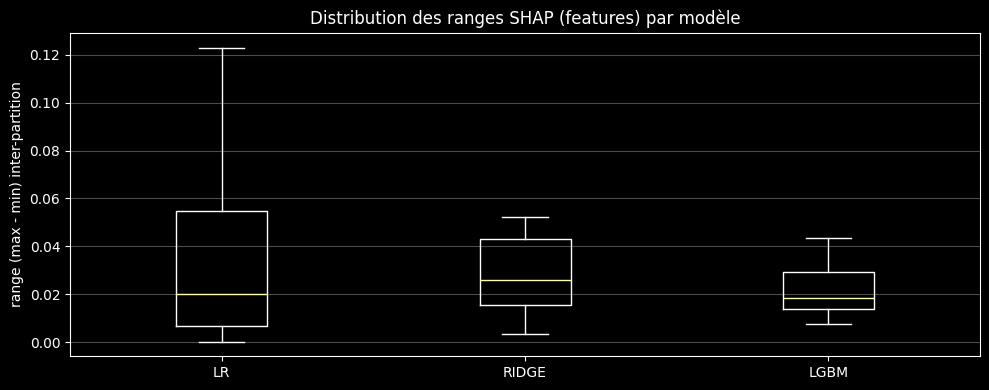

In [24]:
import matplotlib.pyplot as plt

data = [results_variation[m]["range"].dropna().values for m in results_variation.keys()]
labels = list(results_variation.keys())

plt.figure(figsize=(10,4))
plt.boxplot(data, labels=labels, showfliers=False)
plt.title("Distribution des ranges SHAP (features) par modèle")
plt.ylabel("range (max - min) inter-partition")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

Le graphique montre que la dispersion des importances SHAP varie sensiblement selon le modèle.

La régression linéaire (LR) présente la plus forte variabilité. Certaines variables dominent fortement selon les cas, ce qui suggère une structure d’importance instable et parfois très concentrée.

Le Ridge affiche une dispersion plus contenue. La hiérarchie des variables reste marquée, mais plus stable grâce à la régularisation.

LightGBM (LGBM) présente la distribution la plus compacte. L’importance est davantage répartie entre les variables. Elle capte mieux l'enmeble de impact de facteur exogène. 

En résumé, LR est plus instable, Ridge plus régularisé, et LGBM plus structuré et homogène dans l’utilisation des variables.

# Analye détailée

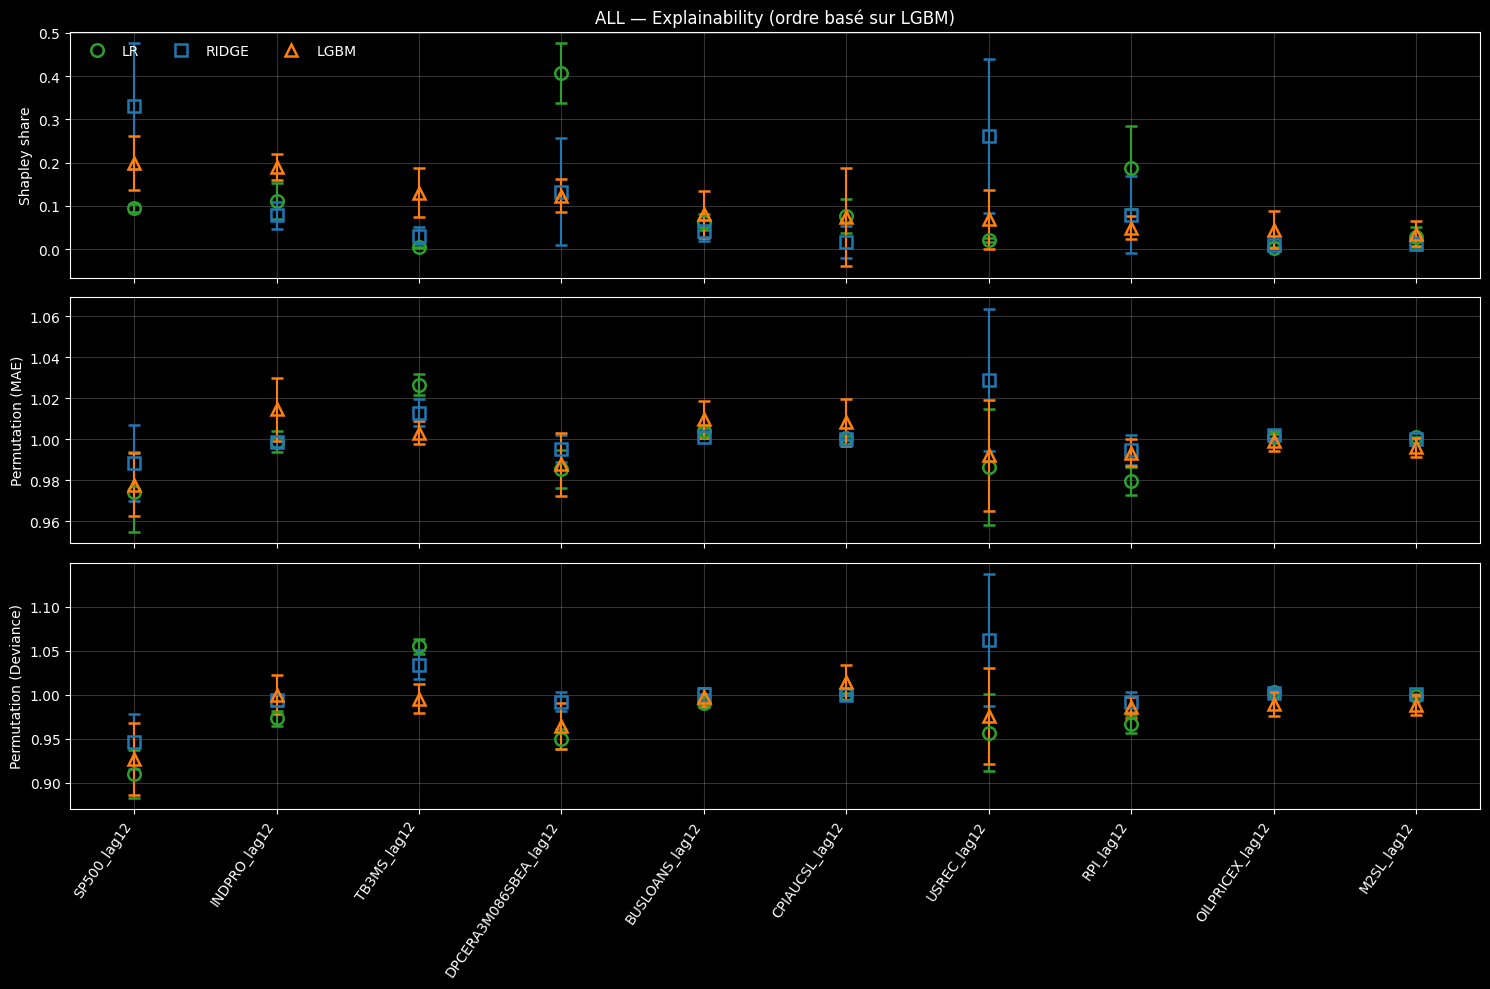

In [25]:
# ============================================================
# Même graphique mais pour ALL uniquement
# Juxtaposition multi-modèles — ordre basé sur LGBM (ALL)
# 3 lignes (metrics) x 1 partition ("ALL")
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("dark_background")

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def _prep_perm_df(df):
    if df is None or not {"feature","ratio_mean"}.issubset(df.columns):
        return None
    out = df[["feature","ratio_mean"]].copy()
    out = out.rename(columns={"ratio_mean":"mean"})
    out["std"] = df["ratio_std"] if "ratio_std" in df.columns else np.nan
    return out.set_index("feature").astype(float)

def _prep_shap_df(df):
    if df is None or not {"feature","shap_share_mean"}.issubset(df.columns):
        return None
    out = df[["feature","shap_share_mean"]].copy()
    out = out.rename(columns={"shap_share_mean":"mean"})
    out["std"] = df["shap_share_std"] if "shap_share_std" in df.columns else np.nan
    return out.set_index("feature").astype(float)

def _model_styles():
    return {
        "LR":    dict(color="#2ca02c", marker="o"),
        "RIDGE": dict(color="#1f77b4", marker="s"),
        "LGBM":  dict(color="#ff7f0e", marker="^"),
    }

def _order_by_lgbm(shap_map, top_k):
    df_lgbm = shap_map.get("LGBM")
    if df_lgbm is None:
        return []
    return (
        df_lgbm["mean"]
        .sort_values(ascending=False)
        .head(top_k)
        .index
        .tolist()
    )

# ------------------------------------------------------------
# Plot ALL uniquement
# ------------------------------------------------------------
def plot_importance_ALL_lgbm_order(
    results_shap_share_by_part,
    results_perm_mae_by_part,
    results_perm_dev_by_part,
    models=("LR","RIDGE","LGBM"),
    top_k=12,
    figsize=(15, 10),
    rotate=55,
    markersize=9,
    mew=1.8,
    elinewidth=1.5,
    capsize=4,
    align_vertical=True,   # True => mêmes x pour les 3 modèles
):
    part = "ALL"
    styles = _model_styles()
    row_titles = ["Shapley share", "Permutation (MAE)", "Permutation (Deviance)"]

    # ---- récupérer DF ALL par modèle
    shap_map, pmae_map, pdev_map = {}, {}, {}
    for m in models:
        shap_map[m] = _prep_shap_df(results_shap_share_by_part.get(part, {}).get(m))
        pmae_map[m] = _prep_perm_df(results_perm_mae_by_part.get(part, {}).get(m))
        pdev_map[m] = _prep_perm_df(results_perm_dev_by_part.get(part, {}).get(m))

    # ---- ordre basé sur LGBM (ALL)
    order = _order_by_lgbm(shap_map, top_k=top_k)
    if not order:
        raise ValueError("Pas de SHAP LGBM dispo pour la partition ALL (ou DF vide).")

    x = np.arange(len(order))
    panels = [shap_map, pmae_map, pdev_map]

    fig, axes = plt.subplots(3, 1, figsize=figsize, sharex=True)

    for row, ax in enumerate(axes):
        data_map = panels[row]

        for m in models:
            dfm = data_map.get(m)
            if dfm is None:
                continue

            M = dfm.reindex(order)
            y = M["mean"].values
            yerr = M["std"].values if "std" in M.columns else None
            if yerr is not None and np.all(~np.isfinite(yerr)):
                yerr = None

            st = styles[m]

            xv = x if align_vertical else x  # (ici align_vertical True => même x)

            ax.errorbar(
                xv, y, yerr=yerr,
                fmt=st["marker"],
                ms=markersize, mew=mew, mfc="none",
                elinewidth=elinewidth, ecolor=st["color"],
                capsize=capsize,
                linestyle="none",
                color=st["color"]
            )

        ax.set_ylabel(row_titles[row])
        ax.grid(True, alpha=0.2)

    axes[0].set_title("ALL — Explainability (ordre basé sur LGBM)")
    axes[-1].set_xticks(x)
    axes[-1].set_xticklabels(order, rotation=rotate, ha="right")

    # ---- légende
    handles = [
        plt.Line2D([], [], marker=styles[m]["marker"], linestyle="none",
                   color=styles[m]["color"], label=m,
                   markerfacecolor="none", markeredgewidth=mew, markersize=markersize)
        for m in models
    ]
    axes[0].legend(handles=handles, loc="upper left", frameon=False, ncol=len(handles))

    plt.tight_layout()
    return fig


# ============================================================
# APPEL — ALL
# ============================================================
fig = plot_importance_ALL_lgbm_order(
    results_shap_share_by_part=results_shap_share_by_part,
    results_perm_mae_by_part=results_perm_mae_by_part,
    results_perm_dev_by_part=results_perm_dev_by_part,
    models=("LR","RIDGE","LGBM"),
    top_k=12,
    figsize=(15, 10),
    rotate=55
)

plt.show()

# Pourcentage de représentation

In [26]:
# ============================================================
# % de représentation de LGBM dans les top_k features affichées
# ============================================================

part = "ALL"
top_k = 12

df_lgbm = _prep_shap_df(results_shap_share_by_part.get(part, {}).get("LGBM"))

if df_lgbm is None or df_lgbm.empty:
    raise ValueError("Pas de SHAP LGBM dispo pour ALL.")

# ordre des top_k features LGBM
top_features = (
    df_lgbm["mean"]
    .sort_values(ascending=False)
    .head(top_k)
)

# somme top_k
top_sum = top_features.sum()

# somme totale
total_sum = df_lgbm["mean"].sum()

# pourcentage de représentation
pct_repr = 100 * top_sum / total_sum if total_sum != 0 else np.nan

print(f"Représentation de LGBM par les {top_k} features affichées : {pct_repr:.2f}%")

Représentation de LGBM par les 12 features affichées : 100.00%


In [27]:
pct_table = (top_features / total_sum * 100).rename("pct_lgbm")
print(pct_table.round(2))

feature
SP500_lag12              19.95
INDPRO_lag12             19.01
TB3MS_lag12              13.11
DPCERA3M086SBEA_lag12    12.40
BUSLOANS_lag12            8.09
CPIAUCSL_lag12            7.43
USREC_lag12               6.96
RPI_lag12                 5.00
OILPRICEX_lag12           4.51
M2SL_lag12                3.55
Name: pct_lgbm, dtype: float64


# Donner le graphique

In [28]:
# ============================================================
# Produire le tableau Top-5 (Rank_1..Rank_5) par (model, partition)
# ✅ Même logique que ton plot : ordre basé sur LGBM (SHAP share)
#    -> pour chaque partition, on prend le Top5 des features de LGBM,
#       puis on met ces features comme Rank_1..Rank_5 pour TOUS les modèles.
# ============================================================

import numpy as np
import pandas as pd

# -----------------------
# Helpers (SHAP)
# -----------------------
def _prep_shap_df(df):
    if df is None or not {"feature","shap_share_mean"}.issubset(df.columns):
        return None
    out = df[["feature","shap_share_mean"]].copy()
    out = out.rename(columns={"shap_share_mean":"mean"})
    return out.set_index("feature").astype(float)

def _order_by_lgbm(results_shap_share_by_part, part, top_k=5):
    df_lgbm = _prep_shap_df(results_shap_share_by_part.get(part, {}).get("LGBM"))
    if df_lgbm is None:
        return []
    return (
        df_lgbm["mean"]
        .sort_values(ascending=False)
        .head(top_k)
        .index
        .tolist()
    )

# -----------------------
# Build pivot table
# -----------------------
models = ["LGBM", "LR", "RIDGE"]   # ordre d’affichage
partitions_order = ["1990-1999", "2000-2008", "2009-2019", "2020-end"]
top_k = 5

rows = []
for part in partitions_order:
    order_feats = _order_by_lgbm(results_shap_share_by_part, part, top_k=top_k)
    if not order_feats:
        continue

    for m in models:
        row = {
            "model": m,
            "partition": part,
        }
        for i in range(top_k):
            row[f"Rank_{i+1}"] = order_feats[i] if i < len(order_feats) else np.nan
        rows.append(row)

rank_table = pd.DataFrame(rows)

# Tri propre + index "rank" comme dans ton exemple
rank_table = (
    rank_table
    .sort_values(["model","partition"])
    .reset_index(drop=True)
    .reset_index()
    .rename(columns={"index":"rank"})
)

rank_table

,rank,model,partition,Rank_1,Rank_2,Rank_3,Rank_4,Rank_5
0,0,LGBM,1990-1999,INDPRO_lag12,SP500_lag12,TB3MS_lag12,DPCERA3M086SBEA_lag12,BUSLOANS_lag12
1,1,LGBM,2000-2008,INDPRO_lag12,SP500_lag12,DPCERA3M086SBEA_lag12,TB3MS_lag12,CPIAUCSL_lag12
2,2,LGBM,2009-2019,SP500_lag12,INDPRO_lag12,TB3MS_lag12,DPCERA3M086SBEA_lag12,USREC_lag12
3,3,LGBM,2020-end,SP500_lag12,INDPRO_lag12,TB3MS_lag12,DPCERA3M086SBEA_lag12,USREC_lag12
4,4,LR,1990-1999,INDPRO_lag12,SP500_lag12,TB3MS_lag12,DPCERA3M086SBEA_lag12,BUSLOANS_lag12
5,5,LR,2000-2008,INDPRO_lag12,SP500_lag12,DPCERA3M086SBEA_lag12,TB3MS_lag12,CPIAUCSL_lag12
6,6,LR,2009-2019,SP500_lag12,INDPRO_lag12,TB3MS_lag12,DPCERA3M086SBEA_lag12,USREC_lag12
7,7,LR,2020-end,SP500_lag12,INDPRO_lag12,TB3MS_lag12,DPCERA3M086SBEA_lag12,USREC_lag12
8,8,RIDGE,1990-1999,INDPRO_lag12,SP500_lag12,TB3MS_lag12,DPCERA3M086SBEA_lag12,BUSLOANS_lag12
9,9,RIDGE,2000-2008,INDPRO_lag12,SP500_lag12,DPCERA3M086SBEA_lag12,TB3MS_lag12,CPIAUCSL_lag12


Voici une **rédaction concise et structurée** :

---

Across all periods, the three models (LR, RIDGE, LGBM) produce a highly consistent ranking of macroeconomic drivers. This indicates that the signal is structural rather than model-dependent.

For 1990–2008, **industrial production (INDPRO)** dominates, followed by the **SP500**. Unemployment dynamics are primarily driven by real economic activity, with financial markets playing a secondary role.

From 2009 onward, the ranking shifts: **SP500 becomes the leading predictor**, ahead of industrial production. This reflects a more financialized regime in which markets anticipate real economic conditions.

After 2020, the structure remains similar, but the **recession dummy (USREC)** enters the Top 5. In crisis periods, regime effects become explicitly informative.

Model-wise, LGBM shows stronger adaptability to regime changes due to its non-linear structure. LR confirms that relationships are largely linear and economically interpretable. RIDGE reinforces robustness by controlling for multicollinearity without altering the hierarchy.

Overall, the stability of rankings across models and their evolution across regimes strongly support H2: exogenous macroeconomic variables significantly enhance unemployment forecasting, especially during structural breaks.


# Reprézentation per partition

In [44]:
# ============================================================
# Tableau Top-5 LGBM avec % affiché sous le nom de la variable
# ============================================================

import numpy as np
import pandas as pd

def _prep_shap_df(df):
    if df is None or not {"feature", "shap_share_mean"}.issubset(df.columns):
        return None
    out = df[["feature","shap_share_mean"]].copy()
    out = out.rename(columns={"shap_share_mean":"mean"})
    return out.set_index("feature").astype(float)

partitions_order = ["1990-1999", "2000-2008", "2009-2019", "2020-end"]
top_k = 5

rows = []

for part in partitions_order:

    df_lgbm = _prep_shap_df(results_shap_share_by_part.get(part, {}).get("LGBM"))
    if df_lgbm is None or df_lgbm.empty:
        continue

    df_lgbm = df_lgbm.sort_values("mean", ascending=False)
    top_df = df_lgbm.head(top_k)

    row = {
        "model": "LGBM",
        "partition": part
    }

    for i, (feat, val) in enumerate(top_df["mean"].items(), start=1):

        pct = round(val * 100, 2)

        row[f"Rank_{i}"] = f"{feat}\n({pct}%)"

    rows.append(row)

rank_table_lgbm = pd.DataFrame(rows)

rank_table_lgbm = (
    rank_table_lgbm
    .reset_index(drop=True)
    .reset_index()
    .rename(columns={"index":"rank"})
)

rank_table_lgbm

,rank,model,partition,Rank_1,Rank_2,Rank_3,Rank_4,Rank_5
0,0,LGBM,1990-1999,INDPRO_lag12\n(19.59%),SP500_lag12\n(19.0%),TB3MS_lag12\n(15.52%),DPCERA3M086SBEA_lag12\n(11.21%),BUSLOANS_lag12\n(10.02%)
1,1,LGBM,2000-2008,INDPRO_lag12\n(19.92%),SP500_lag12\n(19.85%),DPCERA3M086SBEA_lag12\n(13.11%),TB3MS_lag12\n(11.47%),CPIAUCSL_lag12\n(9.18%)
2,2,LGBM,2009-2019,SP500_lag12\n(20.39%),INDPRO_lag12\n(18.08%),TB3MS_lag12\n(12.58%),DPCERA3M086SBEA_lag12\n(12.43%),USREC_lag12\n(8.4%)
3,3,LGBM,2020-end,SP500_lag12\n(20.55%),INDPRO_lag12\n(18.43%),TB3MS_lag12\n(12.85%),DPCERA3M086SBEA_lag12\n(12.83%),USREC_lag12\n(8.36%)


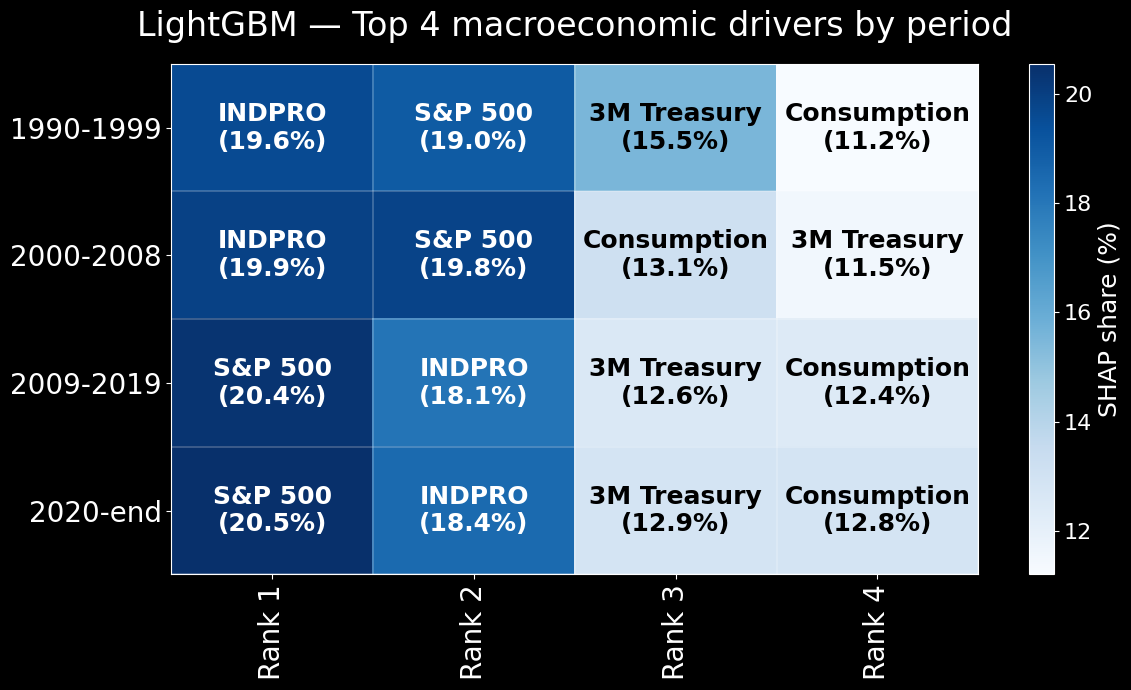

In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("dark_background")


# ============================================================
# Noms courts mais parlants
# ============================================================

FEATURE_NAMES = {
    "INDPRO_lag12": "INDPRO",
    "SP500_lag12": "S&P 500",
    "TB3MS_lag12": "3M Treasury",
    "DPCERA3M086SBEA_lag12": "Consumption",
    "BUSLOANS_lag12": "Business Loans",
    "CPIAUCSL_lag12": "CPI",
    "USREC_lag12": "Recession"
}


# ============================================================
# Helper
# ============================================================

def _prep_shap_df(df):
    if df is None or not {"feature", "shap_share_mean"}.issubset(df.columns):
        return None
    out = df[["feature", "shap_share_mean"]].copy()
    out = out.rename(columns={"shap_share_mean": "mean"})
    return out.set_index("feature").astype(float)


# ============================================================
# Heatmap LGBM Top-3
# dates sur y, ranks sur x
# ============================================================

def plot_lgbm_top3_single_heatmap(
    results_shap_share_by_part,
    partitions_order=("1990-1999","2000-2008","2009-2019","2020-end"),
    top_k=4,
    figsize=(12,7),
    title="LightGBM — Top 4 macroeconomic drivers by period"
):

    values = []
    labels = []

    for part in partitions_order:
        df_lgbm = _prep_shap_df(
            results_shap_share_by_part.get(part, {}).get("LGBM")
        )

        if df_lgbm is None or df_lgbm.empty:
            values.append([np.nan] * top_k)
            labels.append([""] * top_k)
            continue

        top_df = (
            df_lgbm
            .sort_values("mean", ascending=False)
            .head(top_k)
        )

        pct = top_df["mean"].values * 100
        feats = top_df.index.tolist()

        if len(feats) < top_k:
            feats += [""] * (top_k - len(feats))
            pct = np.concatenate([pct, [np.nan] * (top_k - len(pct))])

        values.append(pct)

        labels.append([
            f"{FEATURE_NAMES.get(f, f)}\n({p:.1f}%)"
            if pd.notna(p) and f != ""
            else ""
            for f, p in zip(feats, pct)
        ])

    values = np.array(values)   # pas de .T
    labels = np.array(labels)   # pas de .T

    fig, ax = plt.subplots(figsize=figsize)

    im = ax.imshow(values, aspect="auto", cmap="Blues")

    # x = rank
    ax.set_xticks(np.arange(top_k))
    ax.set_xticklabels(
    [f"Rank {i}" for i in range(1, top_k + 1)],
    fontsize=20,
    rotation=90)

    # y = dates
    ax.set_yticks(np.arange(len(partitions_order)))
    ax.set_yticklabels(partitions_order, fontsize=20)

    # texte avec contraste automatique
    norm = im.norm
    cmap = im.cmap

    for i in range(values.shape[0]):
        for j in range(values.shape[1]):
            txt = labels[i][j]
            if txt:
                val = values[i, j]
                rgba = cmap(norm(val))
                luminance = 0.299 * rgba[0] + 0.587 * rgba[1] + 0.114 * rgba[2]
                text_color = "black" if luminance > 0.6 else "white"

                ax.text(
                    j,
                    i,
                    txt,
                    ha="center",
                    va="center",
                    fontsize=18,
                    color=text_color,
                    fontweight="bold"
                )

    # grille légère
    ax.set_xticks(np.arange(-0.5, top_k, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(partitions_order), 1), minor=True)
    ax.grid(which="minor", color="white", linestyle="-", linewidth=0.3)
    ax.tick_params(which="minor", bottom=False, left=False)

    ax.set_title(title, fontsize=24, pad=20)

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("SHAP share (%)", fontsize=18)
    cbar.ax.tick_params(labelsize=16)

    plt.tight_layout()
    return fig


# ============================================================
# APPEL
# ============================================================

fig = plot_lgbm_top3_single_heatmap(
    results_shap_share_by_part=results_shap_share_by_part
)

plt.show()

Dan le deux graphique, nou analyon non eulement l’importance mai aui la relation des variables explicatives dan la prévision du chômage. Nou avon calculé et utilié  les valeurs de Shapley (SHAP) pour ce faire.

La Figure 1 présente les quatre principaux déterminants macroéconomiques identifiés par le modèle LightGBM pour différentes périodes. Les variables sont classées selon leur part moyenne de SHAP. 

Les résultats montrent que la production industrielle (INDPRO) et l’indice boursier S&P 500 constituent les deux variables les plus influentes de la préviion du chômage américaine. 

A partir de la crie financière de la fin de 2008, la valeur bourière P500 permet d'anticiper le mieux l'évolution de la croiance du chômage une année en avance.

Vous voyez le Les taux d’intérêt à court terme (3M Treasury). c’est le taux auquel le gouvernement américain emprunte de l’argent pour une durée très courte, ici 3 mois. Il reflètte la condition de politique monétaire de la @fed. Avec la consommation, il apparait de manière plus stable comme facteurs secondaires.

Précaution : 
La crie géopolitique actuel pourrait changer cette tendance avec le reurgiement du prix de baril de pétrol. Le prix du baril de Brent est récemment remonté au-dessus de 100 dollars, soit une hausse d’environ 40 à 45 % en un mois, dans un contexte de tensions au Moyen-Orient et de perturbations des flux pétroliers.
Le modèle LGBM ici et auto-adaptatif. Il pourrait bien capter ce changement d'explication du chômage (je vou montre çà une foi le modèle produit le capte). 

Dan le premier graphique, Nous expliquons la contribution de 04 premier variable qui conduient la préviion du taux de chômage par le ML (LightGBM). 

Le variable ont été trié elon la moyenne de part de hapley. 